# CSE437 Final Project - Group No: 38

**20301307** -Md. Fuad Alam

**21201440** -Rashid Iftekhar

**22201736** -Kumar Prothom Pranto Sarma Chowdhury

**24141264** -Dipta Mazumder



# Overview:
**This  dataset provides comprehensive information on individuals, encompassing key attributes such as gender, age, height, weight, family history with overweight, dietary habits, physical activity, transportation mode, and the corresponding obesity level. The dataset is meticulously curated for research and analysis in the domain of health and lifestyle studies.**

Tags:


- **Gender**  
- **Age**  
- **Height**  
- **Weight**  
- **Family_history_with_overweight**  
- **FAVC** (*Frequent consumption of high-caloric food*)  
- **FCVC** (*Frequency of consumption of vegetables*)  
- **NCP** (*Number of main meals*)  
- **CAEC** (*Consumption of food between meals*)  
- **SMOKE**  
- **CH2O** (*Daily water consumption*)  
- **SCC** (*Caloric beverages consumption*)  
- **FAF** (*Physical activity frequency*)  
- **TUE** (*Time spent using technological devices*)  
- **CALC** (*Consumption of alcohol*)  
- **MTRANS** (*Mode of transportation*)  
- **0be1dad** (*Target variable representing obesity level*)  



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [ ]:
df = pd.read_csv("https://drive.usercontent.google.com/download?id=1pTaQEN16mZn0Z-U2DJgKdZ5oONyzXQVe&export=download&authuser=0")

In [ ]:
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
print("This is a multiclass classification problem ")

print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print(f'There are total {df.shape[1]-1} features in the dataset ')

print(f"There are {df.size} data points.")

print(set(df.dtypes))

This is a multiclass classification problem 
Number of rows: 2111
Number of columns: 17
There are total 16 features in the dataset 
There are 35887 data points.
{dtype('O'), dtype('float64')}


In [ ]:
#renaming target columbns
df.rename(columns={'NObeyesdad': 'Obesity_Level'}, inplace=True)
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,Obesity_Level
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
df['Obesity_Level'].value_counts()

,count
Obesity_Level,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


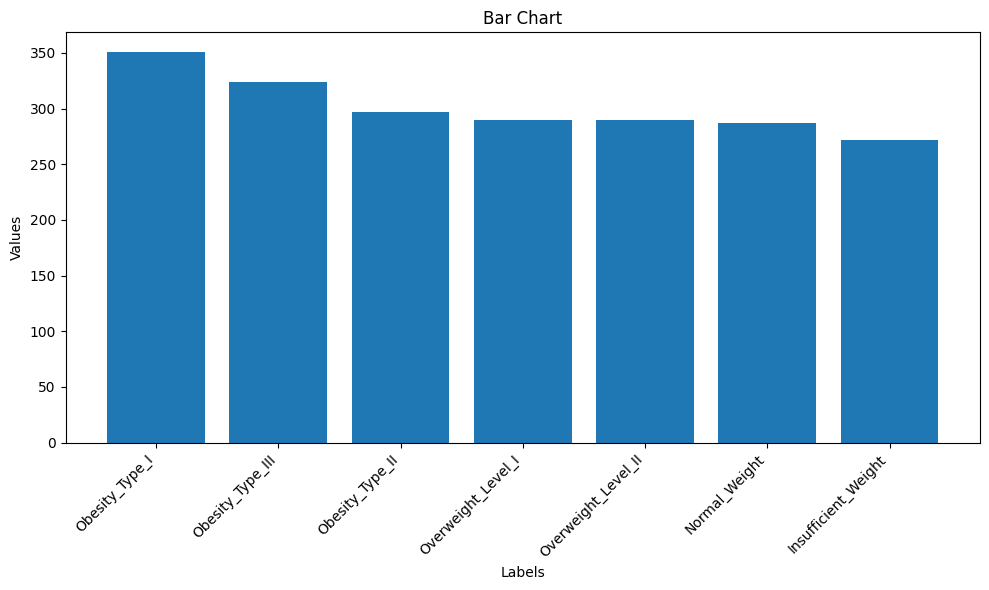

In [ ]:
import matplotlib.pyplot as plt

labels = [
    'Obesity_Type_I',
    'Obesity_Type_III',
    'Obesity_Type_II',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Normal_Weight',
    'Insufficient_Weight'
]

values = [351, 324, 297, 290, 290, 287, 272]

plt.figure(figsize=(10,6))
plt.bar(labels, values)
plt.xlabel('Labels')
plt.ylabel('Values')
plt.title('Bar Chart')

# Rotate labels for readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2100 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2090 non-null   float64
 11  family_history_with_overweight  2090 non-null   object 
 12  FAF                             21

In [ ]:
checking_null = df.isna().sum()
print(checking_null)

categorical_cols = df.select_dtypes(exclude = ['number']).columns.tolist()
print(categorical_cols)

Age                                0
Gender                            11
Height                             0
Weight                             0
CALC                               0
FAVC                               0
FCVC                               0
NCP                                0
SCC                                0
SMOKE                              0
CH2O                              21
family_history_with_overweight    21
FAF                                0
TUE                                0
CAEC                               0
MTRANS                             0
Obesity_Level                      0
dtype: int64
['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight', 'CAEC', 'MTRANS', 'Obesity_Level']


In [ ]:
len(df)

2111

In [ ]:
null_rows = df.isnull().any(axis=1).sum()
print(null_rows)
percentage_of_null = (null_rows*100)/len(df)
print(percentage_of_null,'%')

53
2.510658455708195 %


In [ ]:
null_cols = df.columns[df.isna().any()].tolist()
print(null_cols)

['Gender', 'CH2O', 'family_history_with_overweight']


In [ ]:
#remove null values
for i in null_cols:
  if df[i].dtype == df['Gender'].dtype:
    mode = df[i].mode()[0]
    df[i] = df[i].fillna(mode)
  else:
    median = df[i].median()
    df[i] = df[i].fillna(median)

In [ ]:
df.isna().sum()

,0
Age,0
Gender,0
Height,0
Weight,0
CALC,0
FAVC,0
FCVC,0
NCP,0
SCC,0
SMOKE,0


In [ ]:
print(f"Number of rows before removing duplicates: {df.shape[0]}")
df.drop_duplicates(inplace=True)
print(f"Number of rows after removing duplicates: {df.shape[0]}")

Number of rows before removing duplicates: 2111
Number of rows after removing duplicates: 2088


In [ ]:
import pandas as pd

ORDERED_CLASSES = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

df['Obesity_Level'] = pd.Categorical(df['Obesity_Level'],
                                     categories=ORDERED_CLASSES,
                                     ordered=True)
df['Obesity_Level_Encoded'] = df['Obesity_Level'].cat.codes  # 0..6

print(df[['Obesity_Level', 'Obesity_Level_Encoded']])


            Obesity_Level  Obesity_Level_Encoded
0           Normal_Weight                      1
1           Normal_Weight                      1
2           Normal_Weight                      1
3      Overweight_Level_I                      2
4     Overweight_Level_II                      3
...                   ...                    ...
2106     Obesity_Type_III                      6
2107     Obesity_Type_III                      6
2108     Obesity_Type_III                      6
2109     Obesity_Type_III                      6
2110     Obesity_Type_III                      6

[2088 rows x 2 columns]


In [ ]:
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,Obesity_Level,Obesity_Level_Encoded
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight,1
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,1
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight,1
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I,2
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,3


## Plot distribution of numerical features



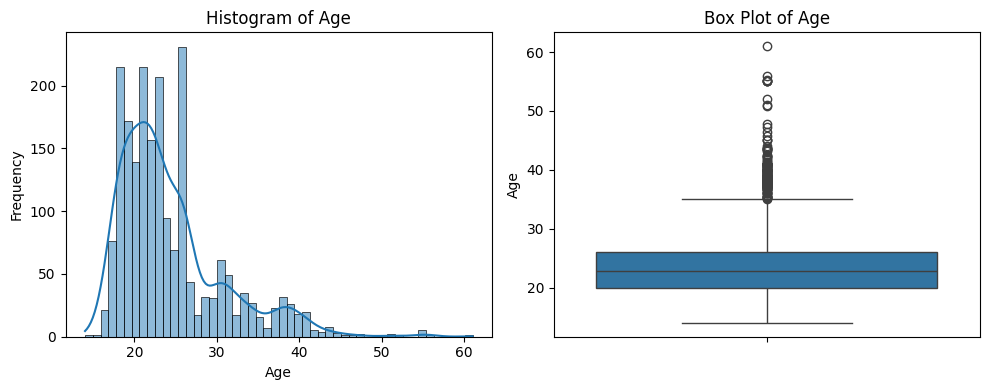

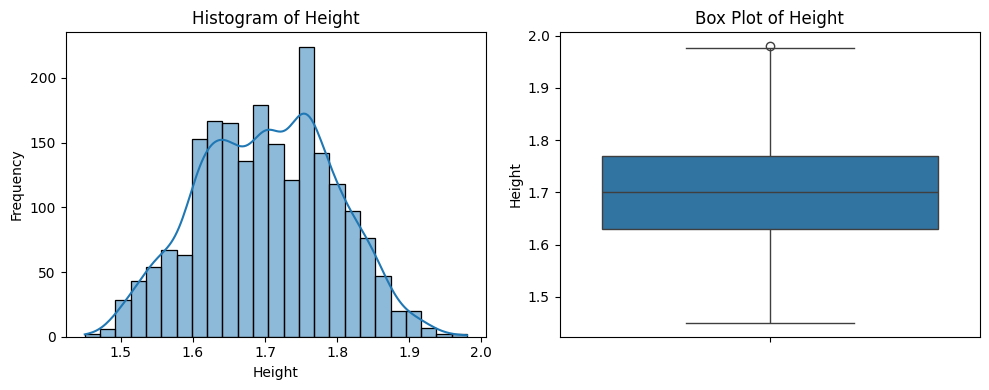

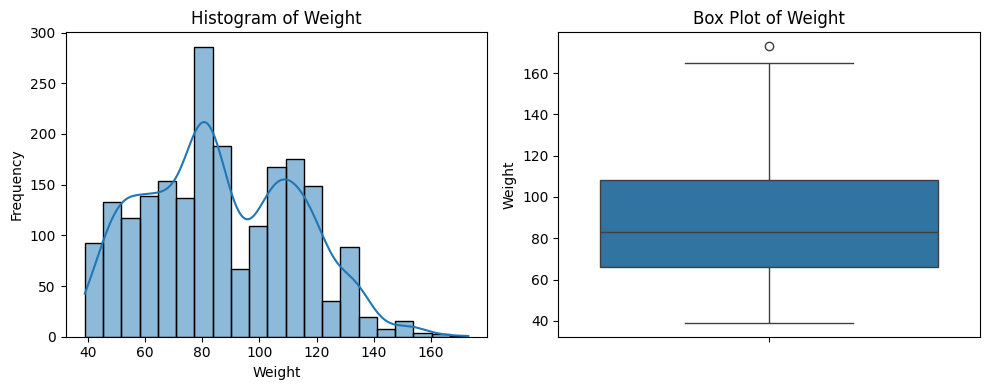

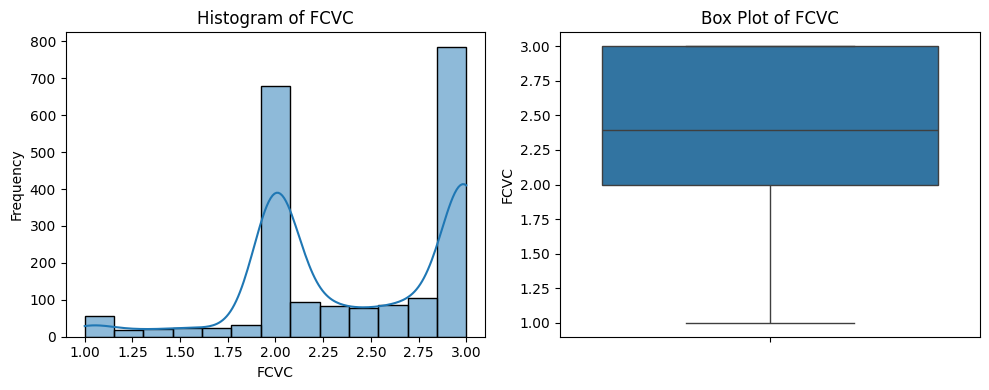

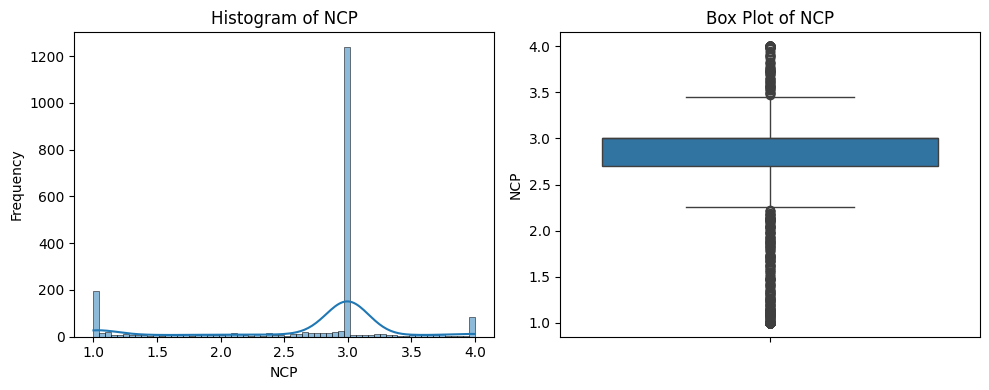

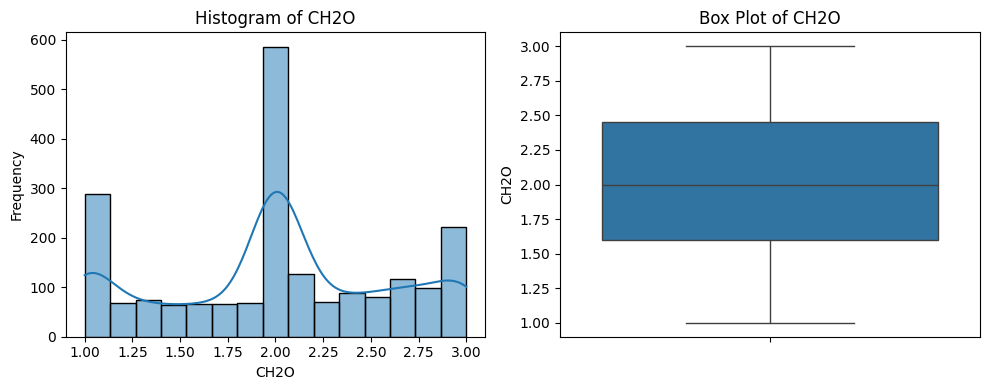

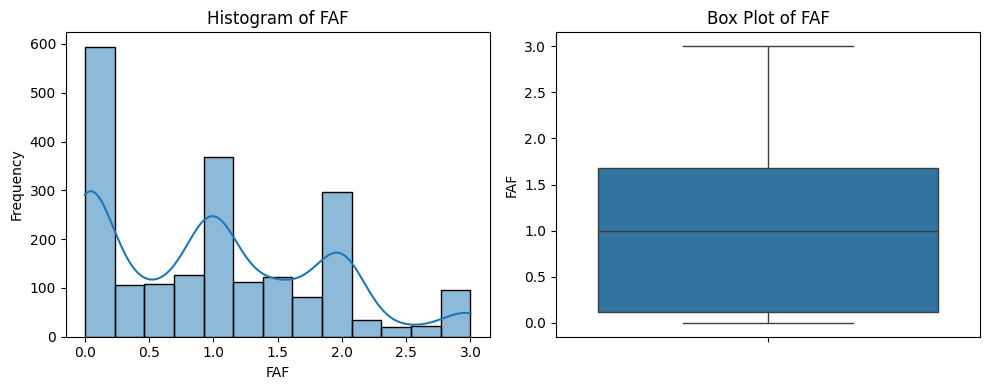

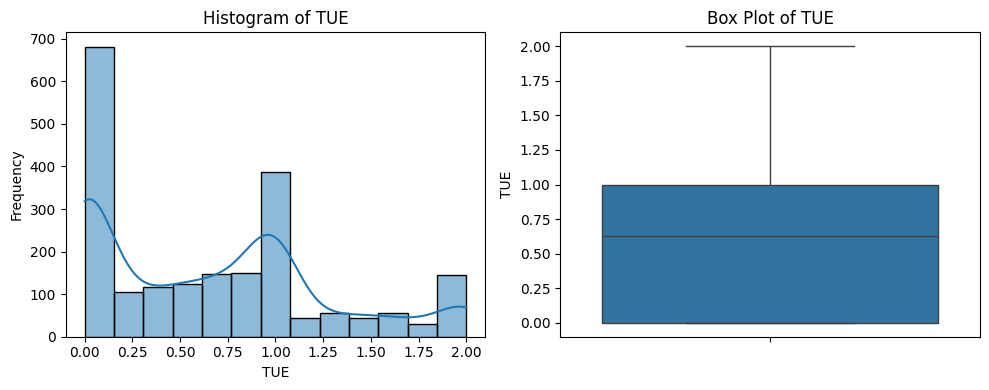

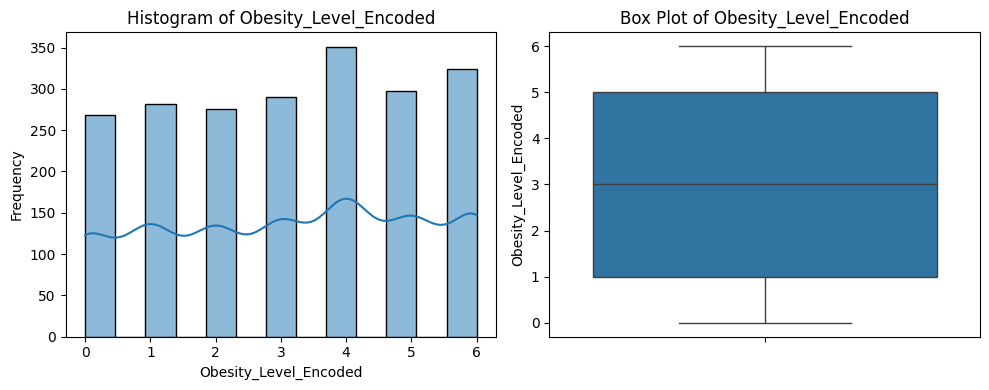

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

## Plot distribution of categorical features


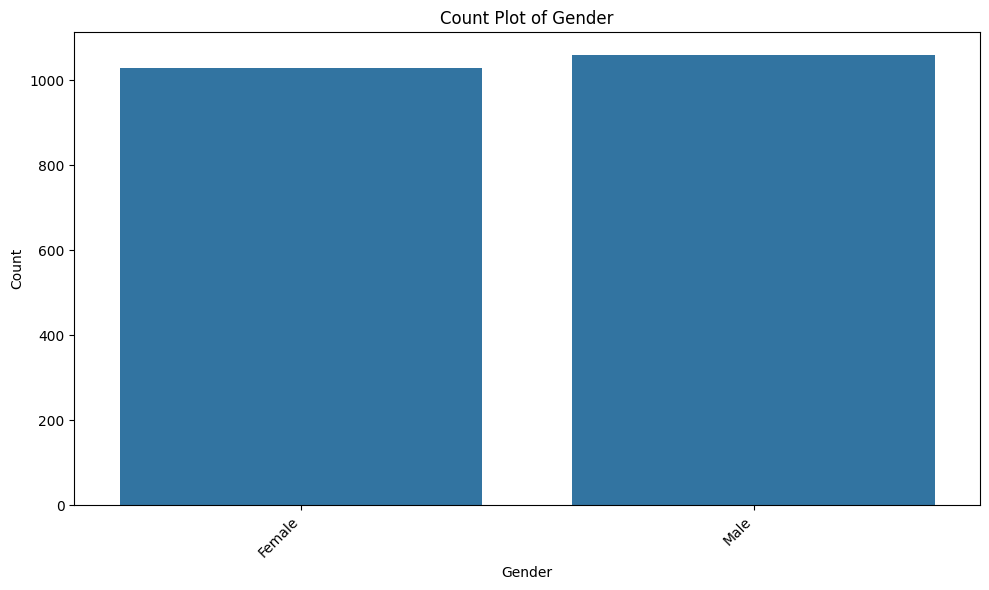

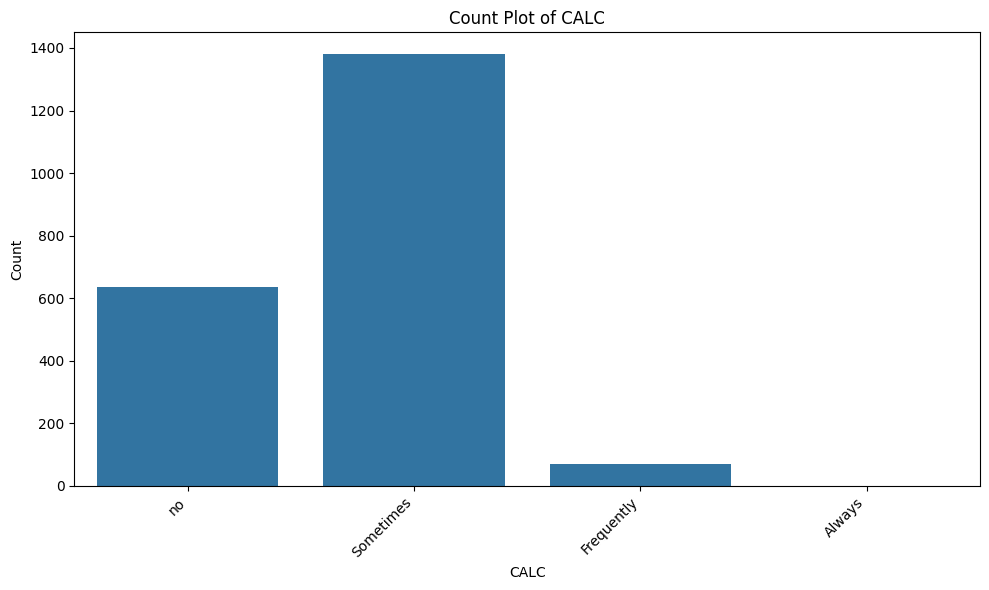

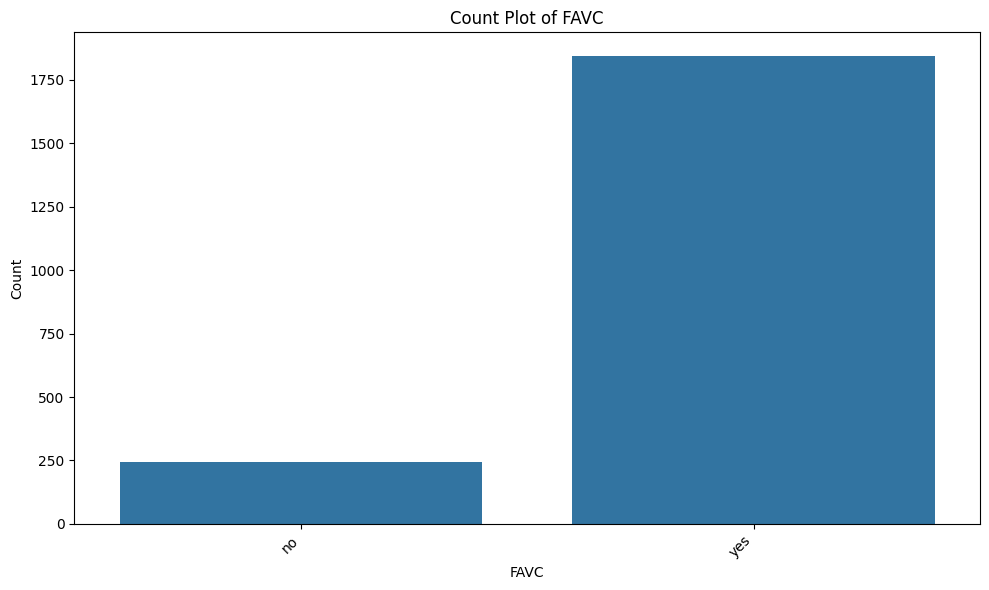

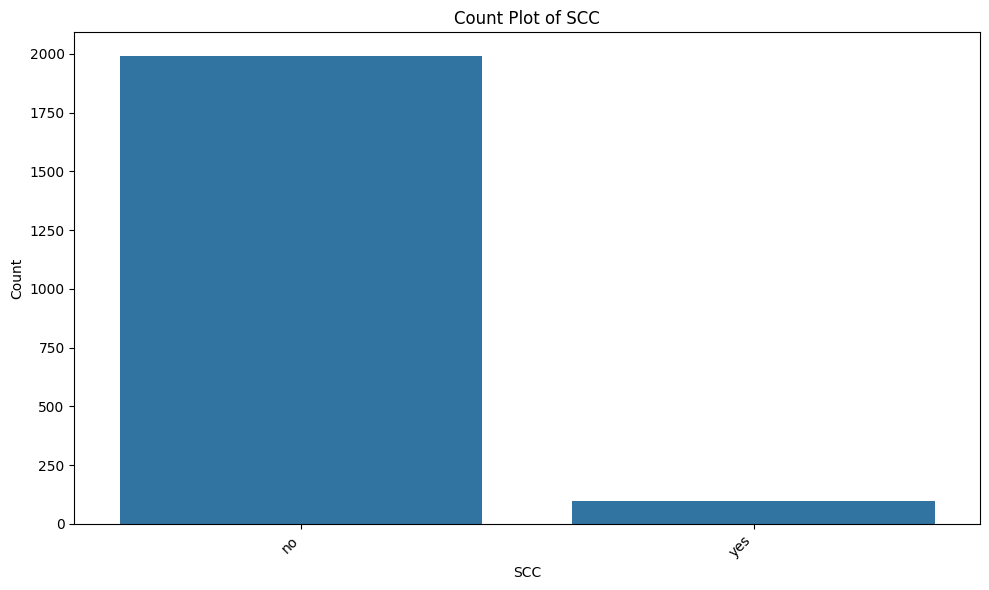

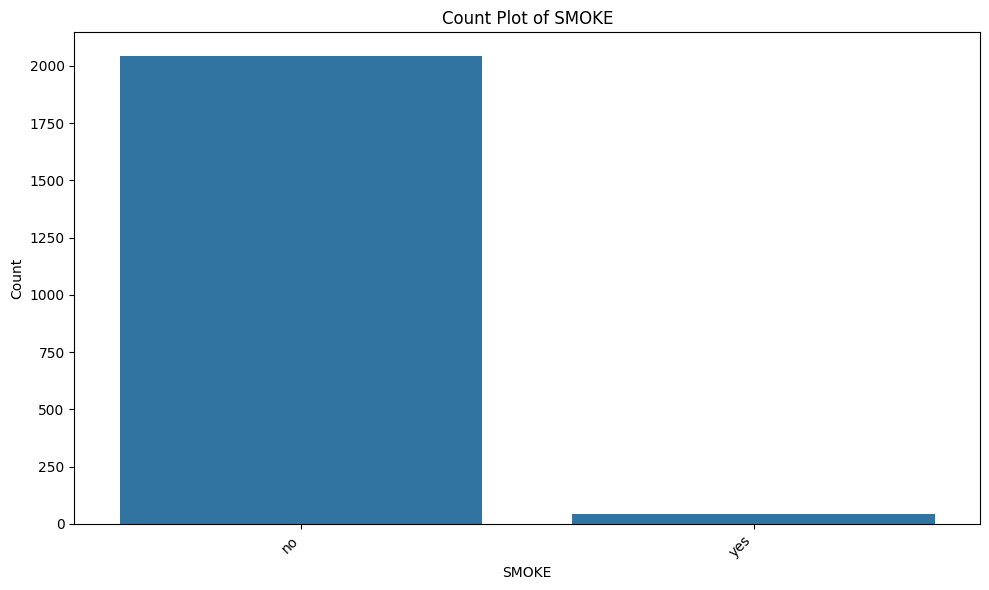

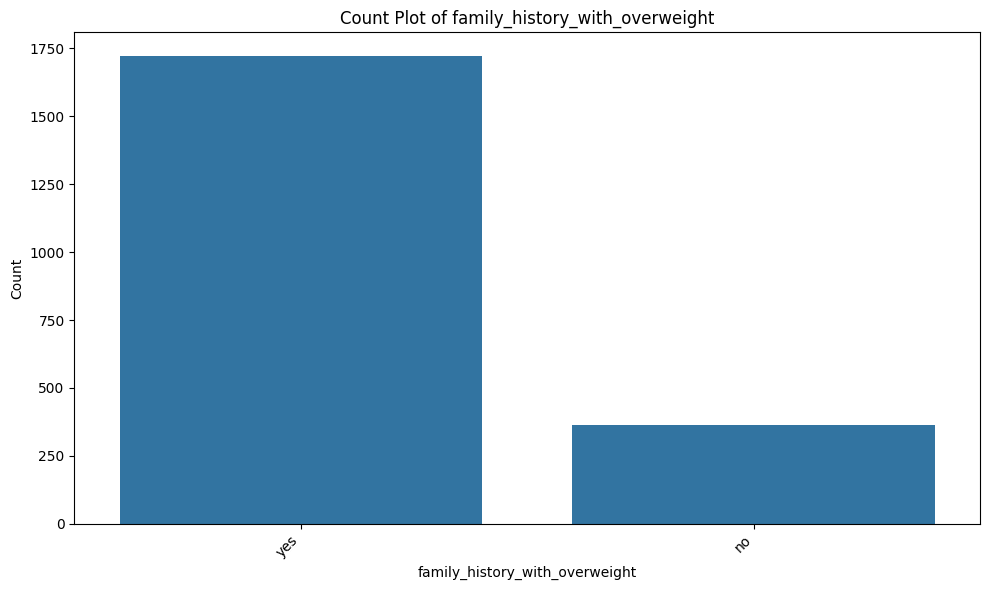

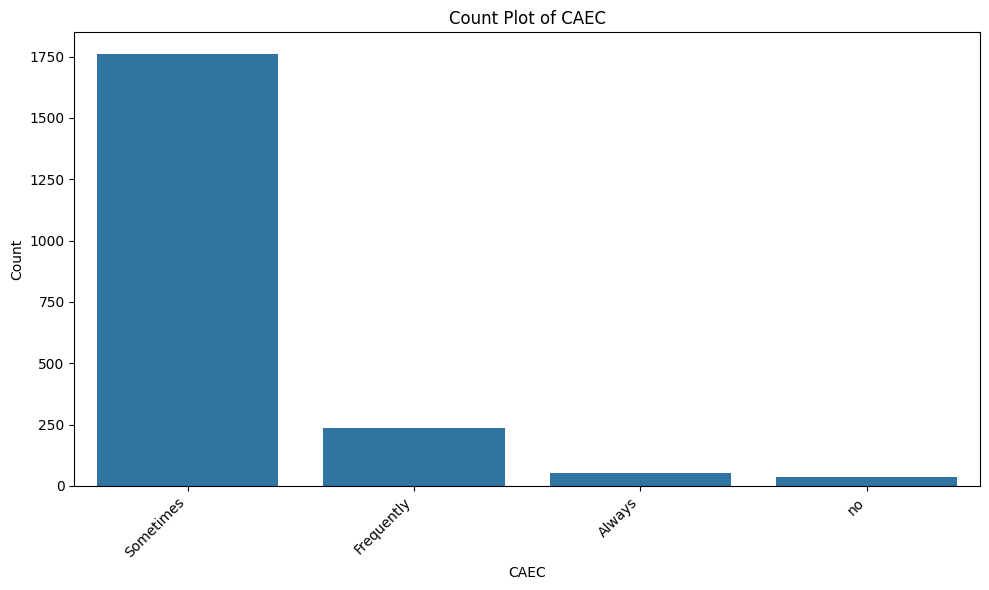

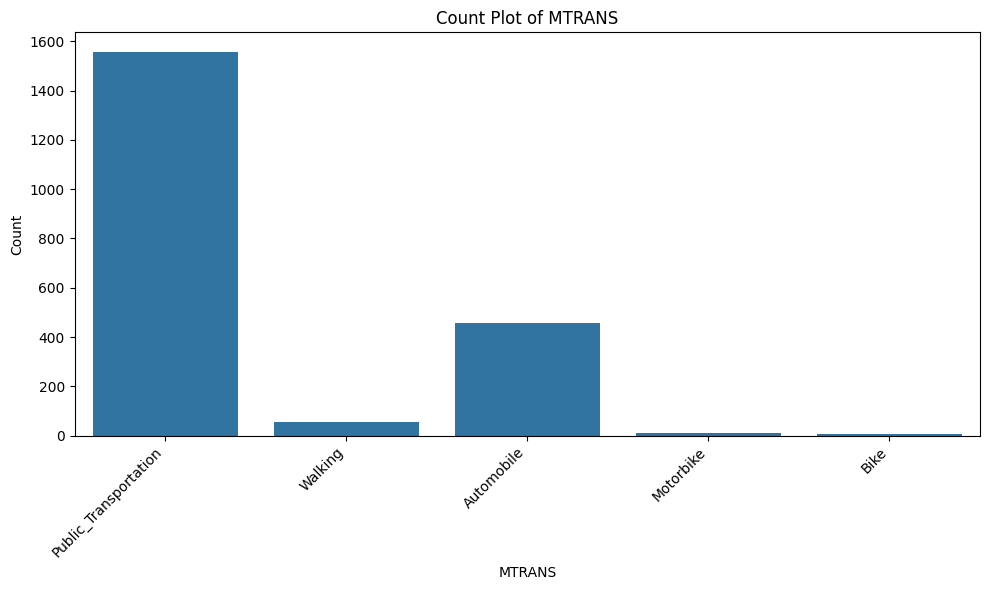

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Plot relationship between numerical features and obesity category



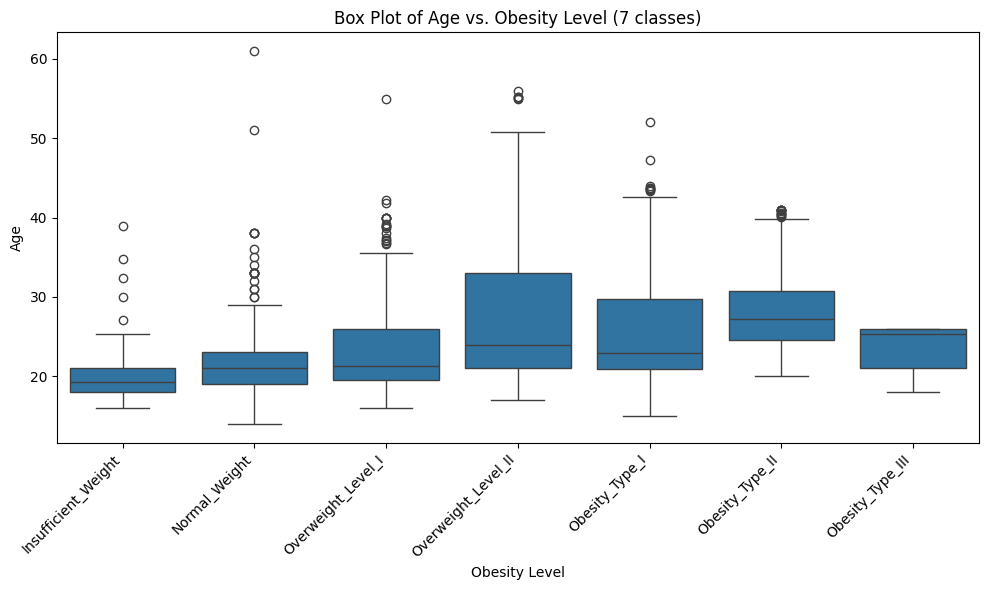

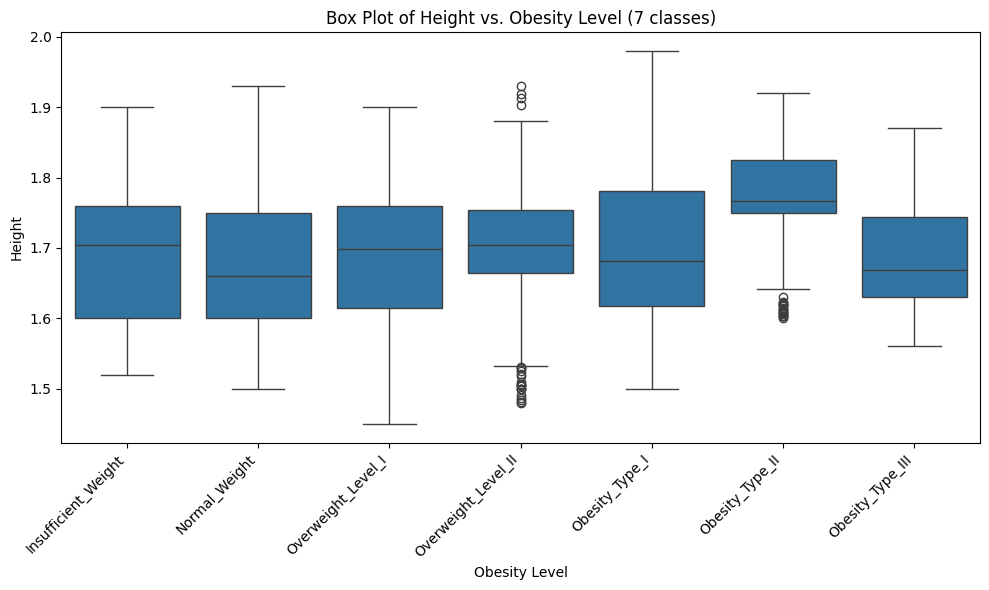

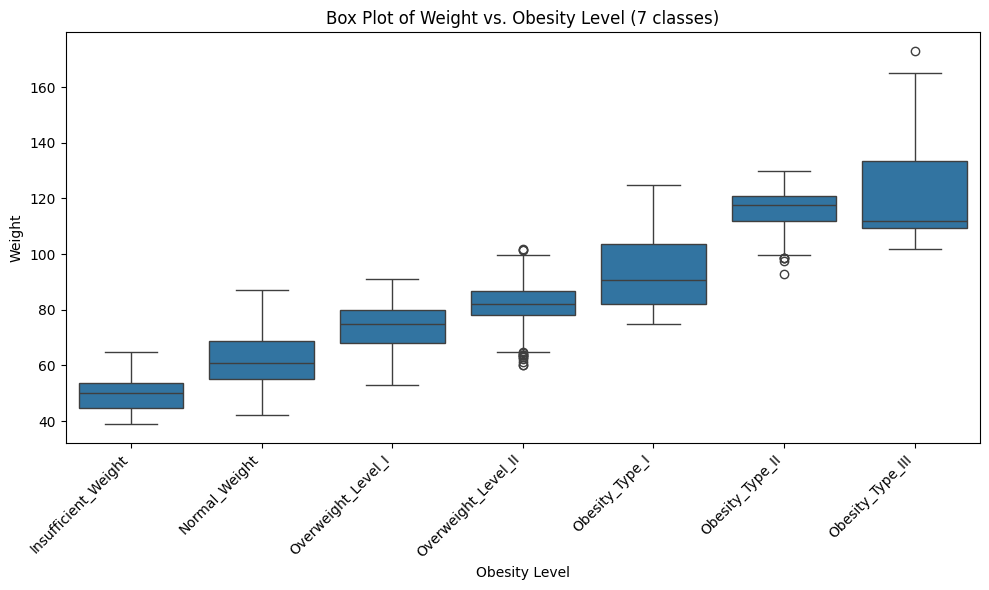

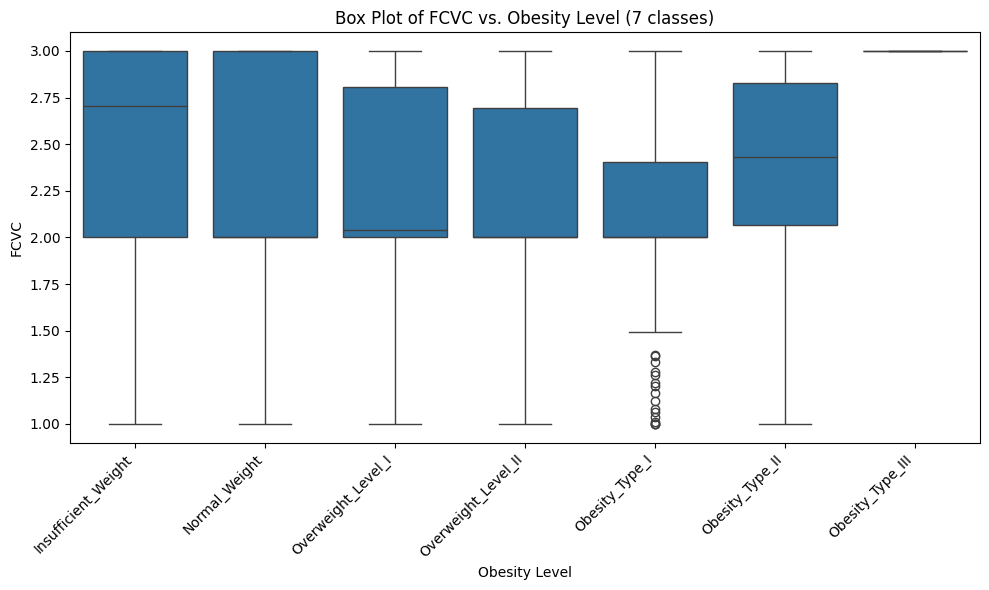

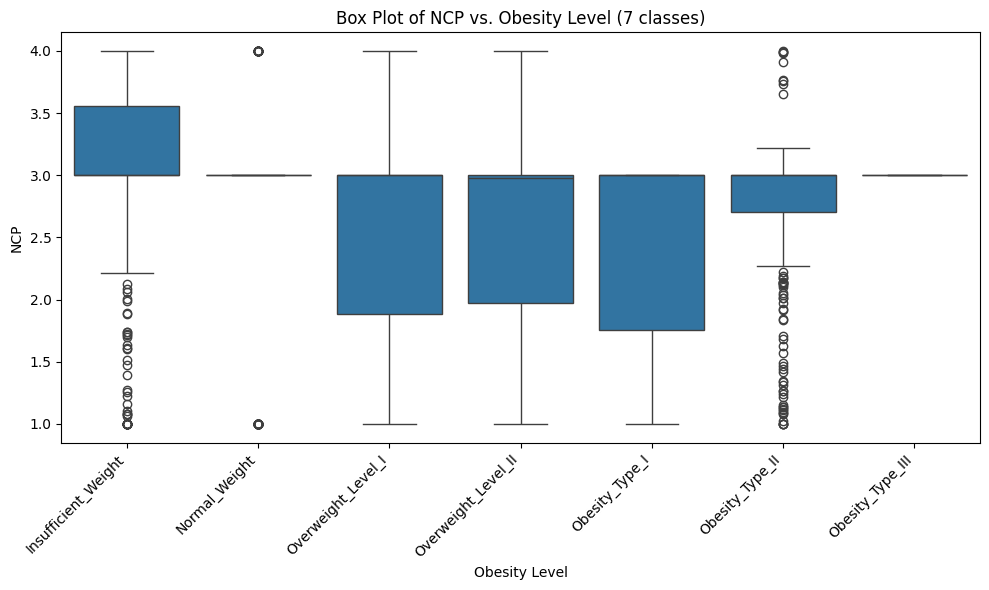

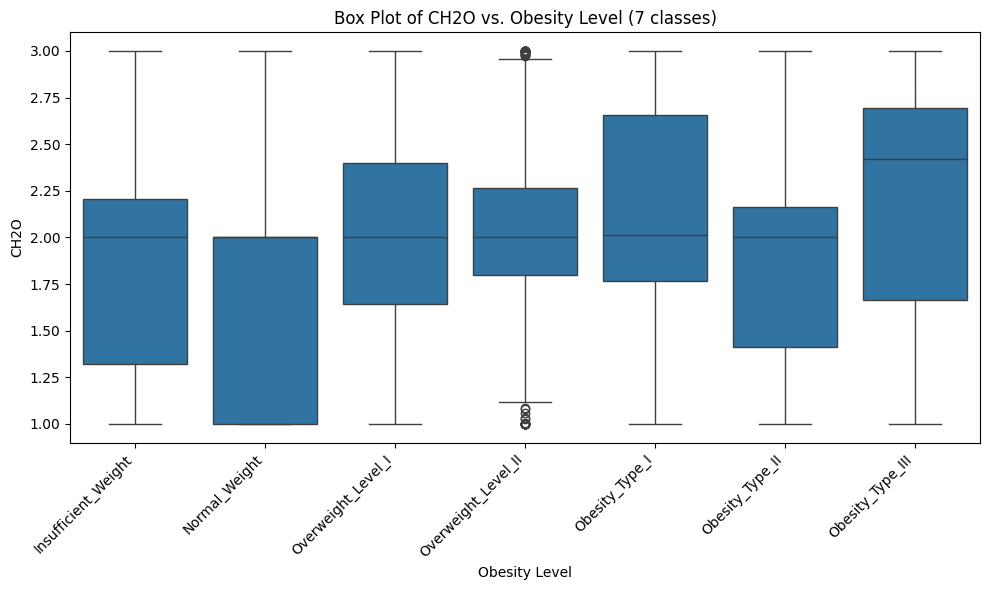

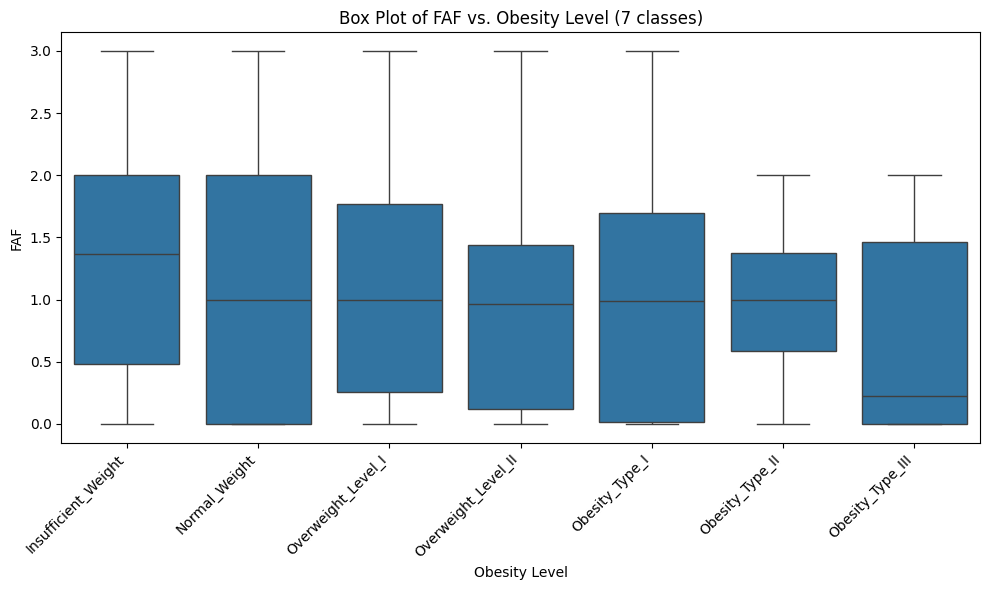

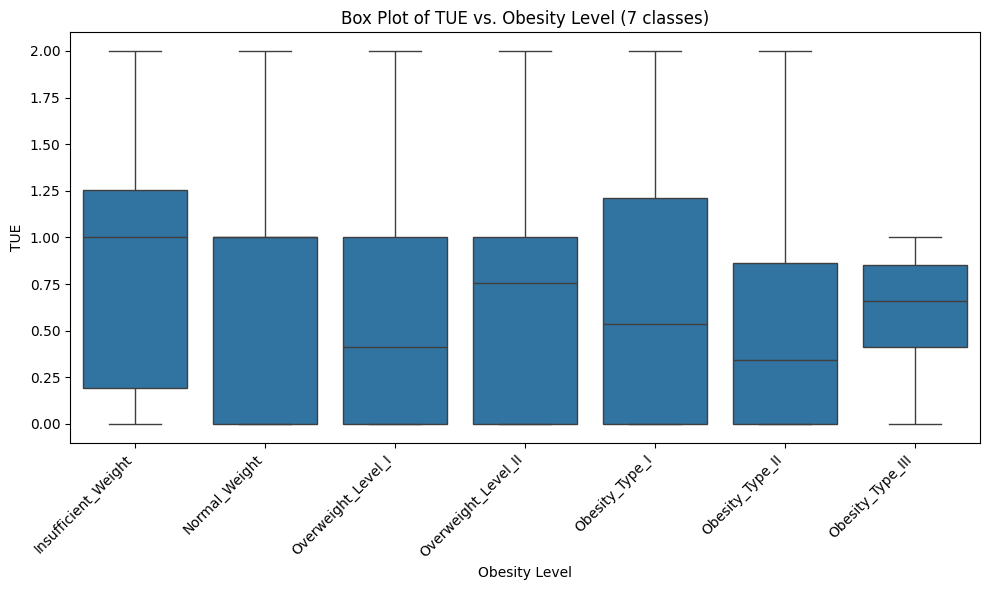

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'Obesity_Level_Encoded' in numerical_cols:
    numerical_cols.remove('Obesity_Level_Encoded')

# Plot boxplots of each numerical feature vs. 7-class target
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Obesity_Level', y=col)
    plt.title(f'Box Plot of {col} vs. Obesity Level (7 classes)')
    plt.xlabel('Obesity Level')
    plt.ylabel(col)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


## Plot relationship between categorical features and obesity category



<Figure size 1000x600 with 0 Axes>

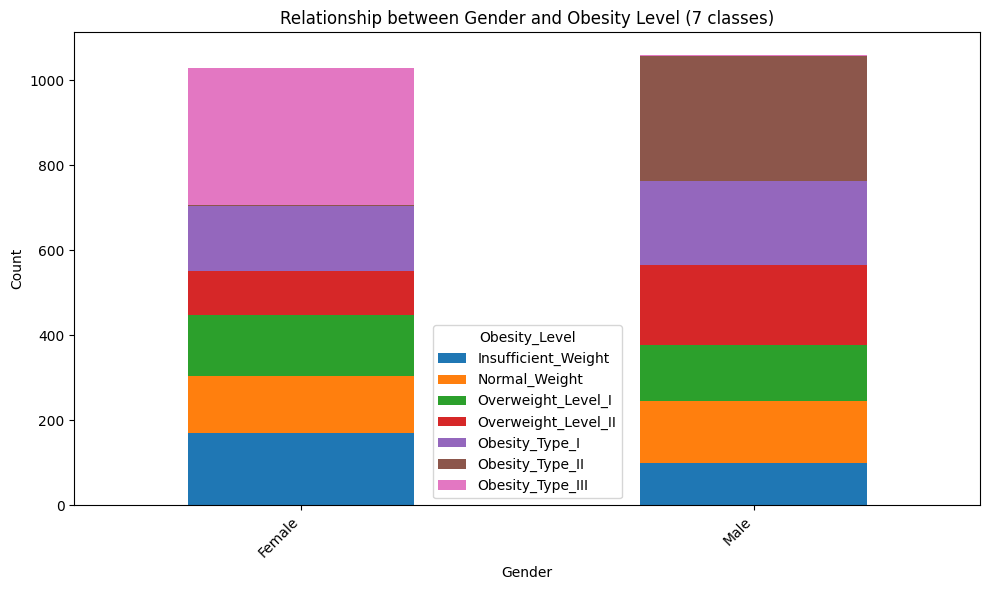

<Figure size 1000x600 with 0 Axes>

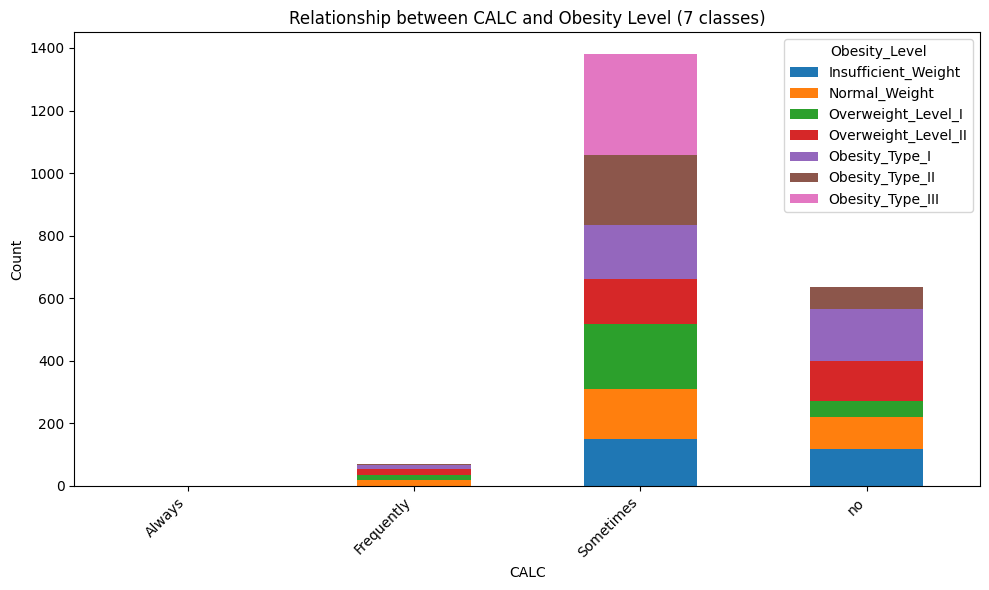

<Figure size 1000x600 with 0 Axes>

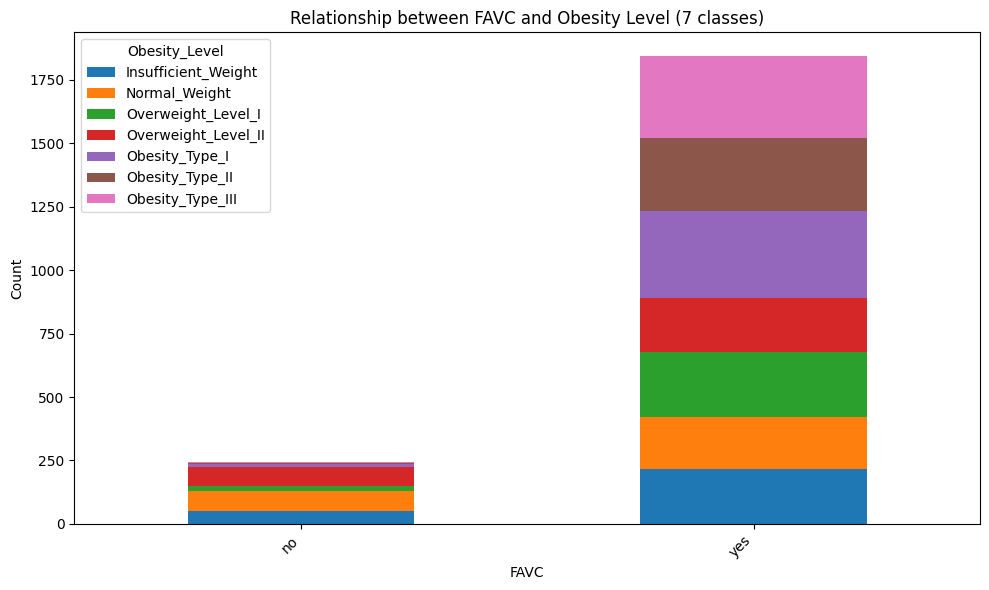

<Figure size 1000x600 with 0 Axes>

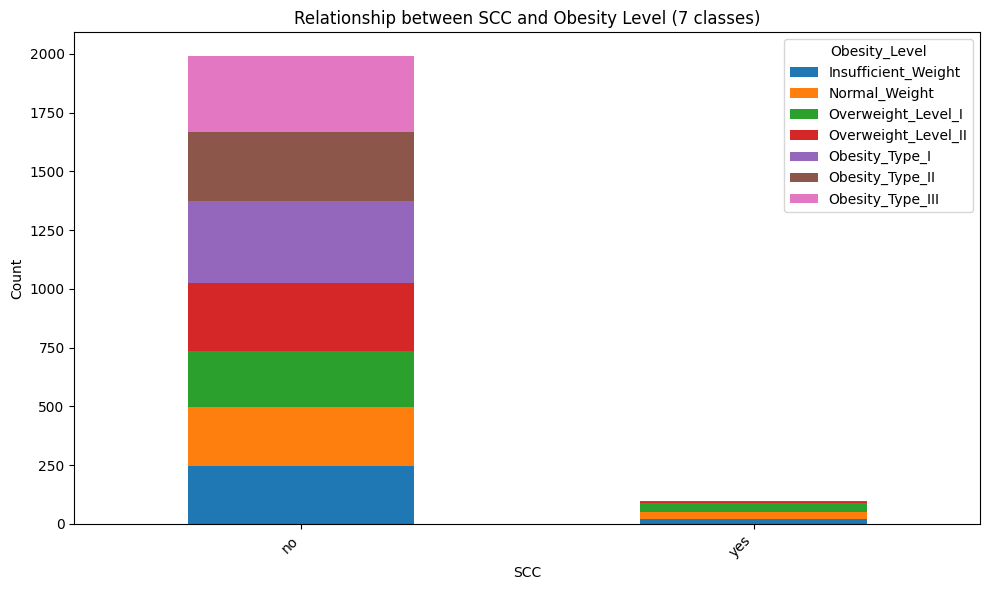

<Figure size 1000x600 with 0 Axes>

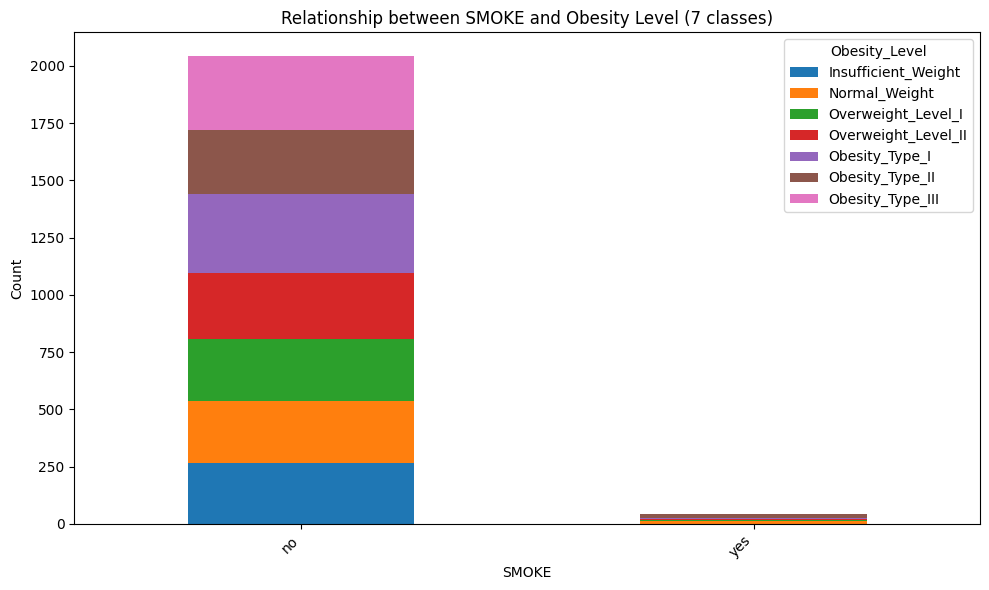

<Figure size 1000x600 with 0 Axes>

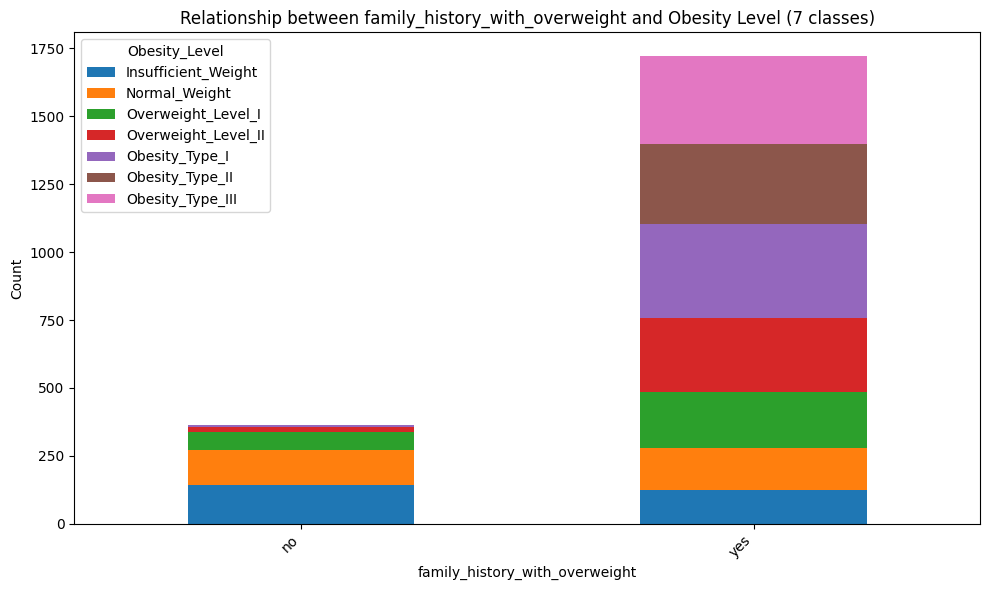

<Figure size 1000x600 with 0 Axes>

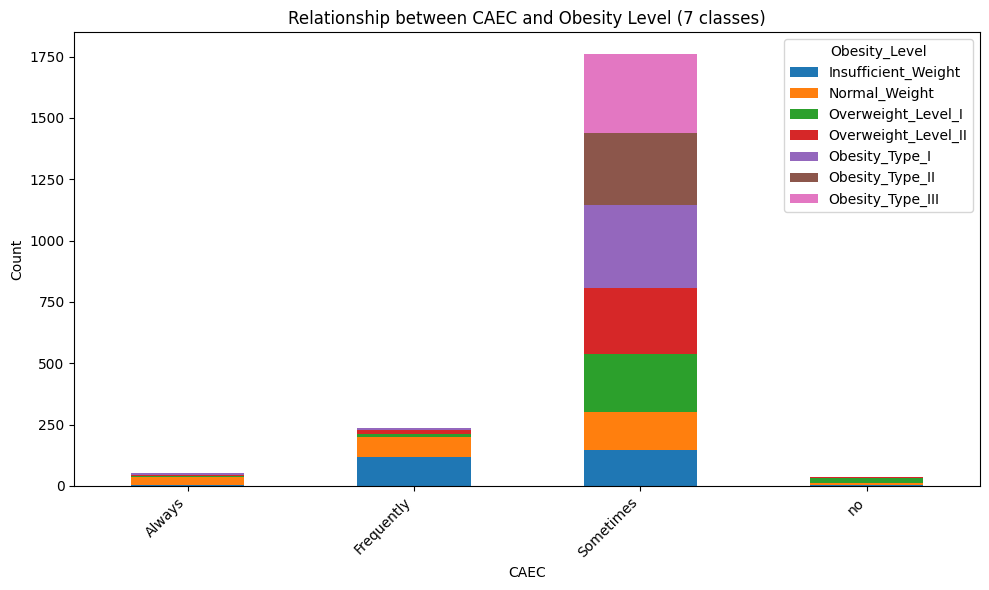

<Figure size 1000x600 with 0 Axes>

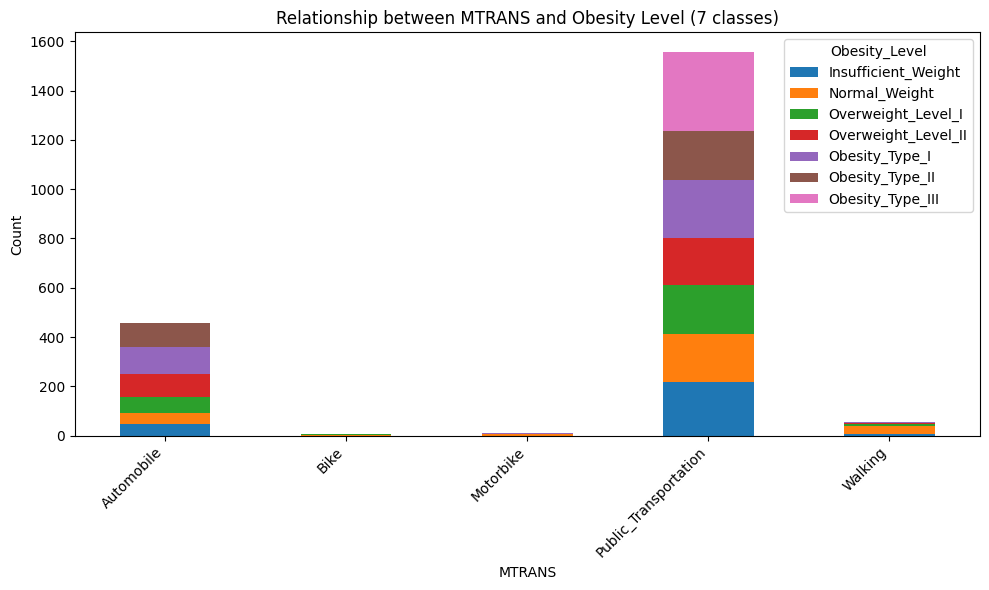

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

if 'Obesity_Level' in categorical_cols:
    categorical_cols.remove('Obesity_Level')

# Plot between categorical feature vs the 7-class target
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    ct = pd.crosstab(df[col], df['Obesity_Level'])
    ct.plot(kind='bar', stacked=True, figsize=(10, 6))
    plt.title(f'Relationship between {col} and Obesity Level (7 classes)')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


## Plot correlation matrix



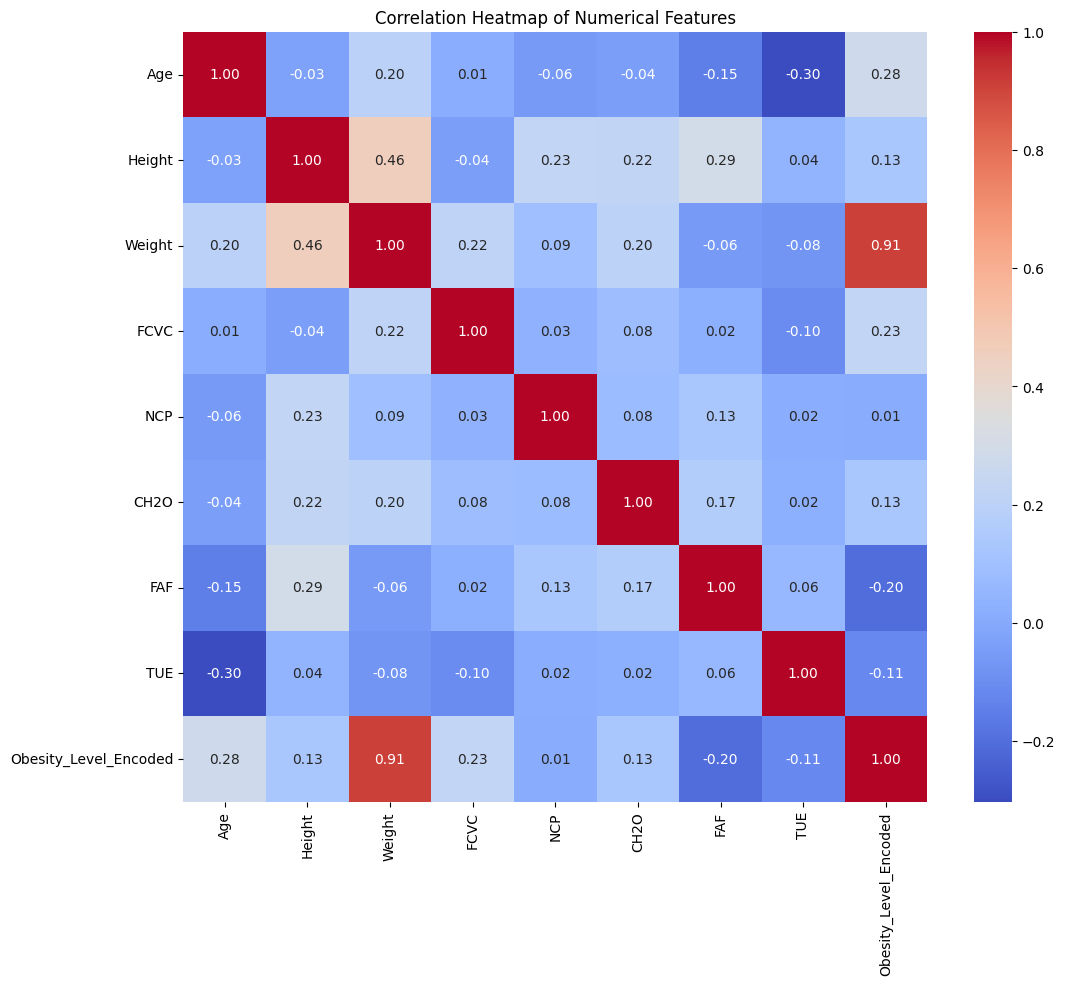

In [ ]:
numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [ ]:
#Feature Engineering to add BMI
df['BMI'] = df['Weight'] / (df['Height'] ** 2)
display(df[['Height', 'Weight', 'BMI']].head())

,Height,Weight,BMI
0,1.62,64.0,24.386526
1,1.52,56.0,24.238227
2,1.80,77.0,23.765432
3,1.80,87.0,26.851852
4,1.78,89.8,28.342381


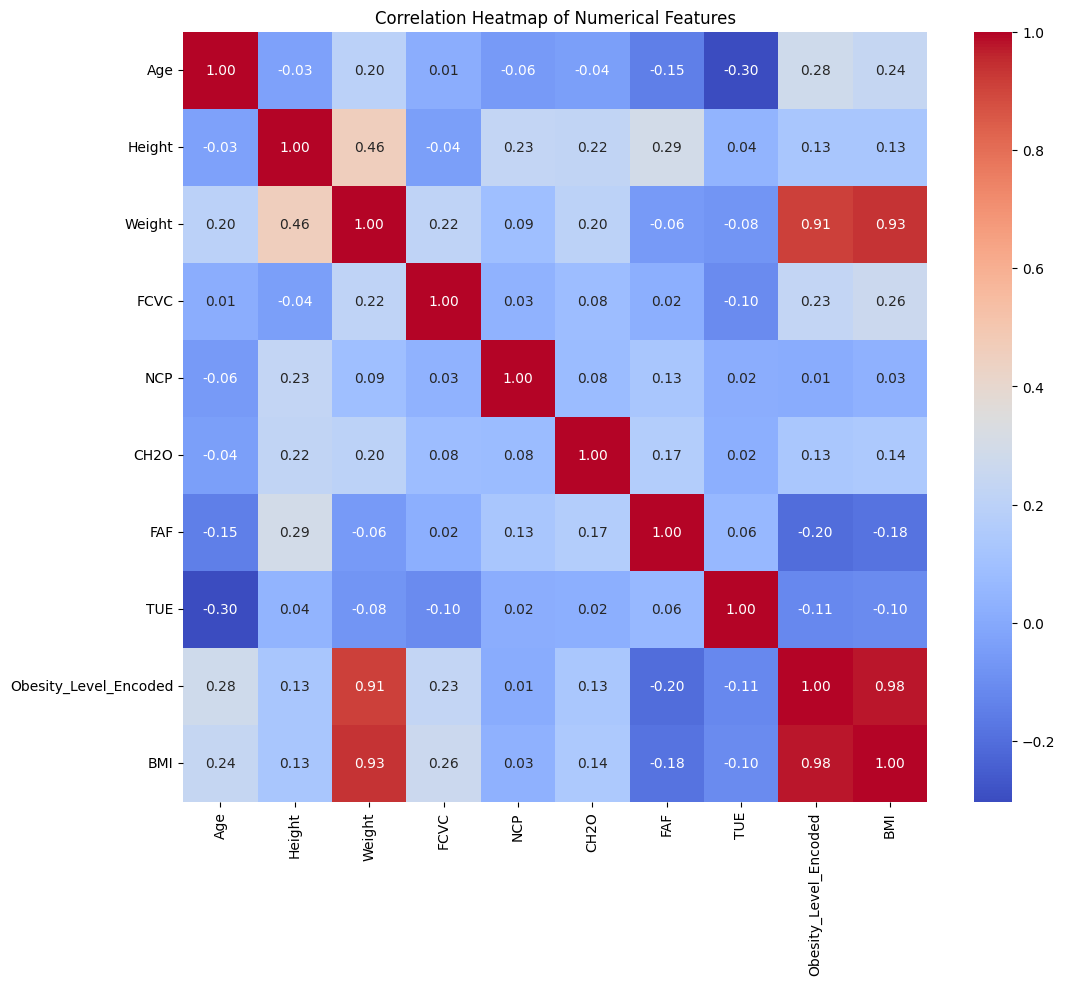

In [ ]:
numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [ ]:
# Identify categorical and numerical columns
categorical_features = df.select_dtypes(include='object').columns.tolist()
numerical_features   = df.select_dtypes(include=np.number).columns.tolist()

# Remove the label columns from these lists if present
for col in ['Obesity_Level', 'Obesity_Category']:
    if col in categorical_features:
        categorical_features.remove(col)

for col in ['Obesity_Level_Encoded', 'Obesity_Category_Encoded']:
    if col in numerical_features:
        numerical_features.remove(col)

print(f"Categorical features: {categorical_features}")
print(f"Numerical features: {numerical_features}")


Categorical features: ['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight', 'CAEC', 'MTRANS']
Numerical features: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']


Scaling and encoding all the features as need


In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd
import numpy as np


X = df.drop(['Obesity_Level', 'Obesity_Level_Encoded',
             'Obesity_Category', 'Obesity_Category_Encoded'],
            axis=1, errors='ignore')
y = df['Obesity_Level_Encoded']  # 7-class target


categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(include=np.number).columns

# Encode part
X_categorical = X[categorical_features].copy()
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    X_categorical[col] = le.fit_transform(X_categorical[col])
    label_encoders[col] = le

# Scale
scaler = StandardScaler()
X_numerical_scaled = scaler.fit_transform(X[numerical_features])
X_numerical_scaled_df = pd.DataFrame(X_numerical_scaled,
                                     columns=numerical_features,
                                     index=X.index)

# Combine scaled numeric and encoded categorical data
X_processed = pd.concat([X_numerical_scaled_df, X_categorical], axis=1)

display(X_processed.head())


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,BMI,Gender,CALC,FAVC,SCC,SMOKE,family_history_with_overweight,CAEC,MTRANS
0,-0.526452,-0.885866,-0.871761,-0.788850,0.391602,-0.008606,-1.186292,0.554708,-0.669610,0,3,0,0,0,1,2,3
1,-0.526452,-1.958516,-1.177143,1.081601,0.391602,1.642932,2.329249,-1.089934,-0.688089,0,2,0,1,1,1,2,3
2,-0.212291,1.044905,-0.375515,-0.788850,0.391602,-0.008606,1.157402,0.554708,-0.747004,1,1,0,0,0,1,2,3
3,0.416030,1.044905,0.006213,1.081601,0.391602,-0.008606,1.157402,-1.089934,-0.362408,1,1,0,0,0,0,2,4
4,-0.369372,0.830375,0.113097,-0.788850,-2.222251,-0.008606,-1.186292,-1.089934,-0.176674,1,2,0,0,0,0,2,3


In [ ]:
from sklearn.model_selection import train_test_split

# Split the processed features and encoded labels
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (1461, 17)
Shape of X_test: (627, 17)
Shape of y_train: (1461,)
Shape of y_test: (627,)


#Model Training

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pandas as pd
import numpy as np


numeric_cols = X.select_dtypes(include=np.number).columns
categorical_cols = X.select_dtypes(include='object').columns

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())
for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])


X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
}

# 4) Train, evaluate, and collect results
evaluation_results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    print(f"Evaluating {name}...")
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    evaluation_results[name] = {
        "accuracy": accuracy,
        "classification_report": report,
        "confusion_matrix": conf_matrix
    }

    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy}")
    print(f"Classification Report:\n{report}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")


evaluation_df = pd.DataFrame({
    'Accuracy': [results['accuracy'] for results in evaluation_results.values()]
}, index=evaluation_results.keys())

print("Model Accuracy Comparison:")
display(evaluation_df)


Training Logistic Regression...
Evaluating Logistic Regression...
--- Logistic Regression ---
Accuracy: 0.89792663476874
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94        81
           1       0.92      0.79      0.85        85
           2       0.78      0.82      0.80        83
           3       0.84      0.83      0.83        87
           4       0.96      0.88      0.92       105
           5       0.89      0.99      0.94        89
           6       0.99      0.99      0.99        97

    accuracy                           0.90       627
   macro avg       0.90      0.90      0.89       627
weighted avg       0.90      0.90      0.90       627

Confusion Matrix:
[[80  1  0  0  0  0  0]
 [ 9 67  8  1  0  0  0]
 [ 0  5 68 10  0  0  0]
 [ 0  0 11 72  4  0  0]
 [ 0  0  0  3 92 10  0]
 [ 0  0  0  0  0 88  1]
 [ 0  0  0  0  0  1 96]]

Training Decision Tree...
Evaluating Decision Tree...
--- Decision Tree

,Accuracy
Logistic Regression,0.897927
Decision Tree,0.955343
Random Forest,0.990431
SVM,0.921850
KNN,0.843700


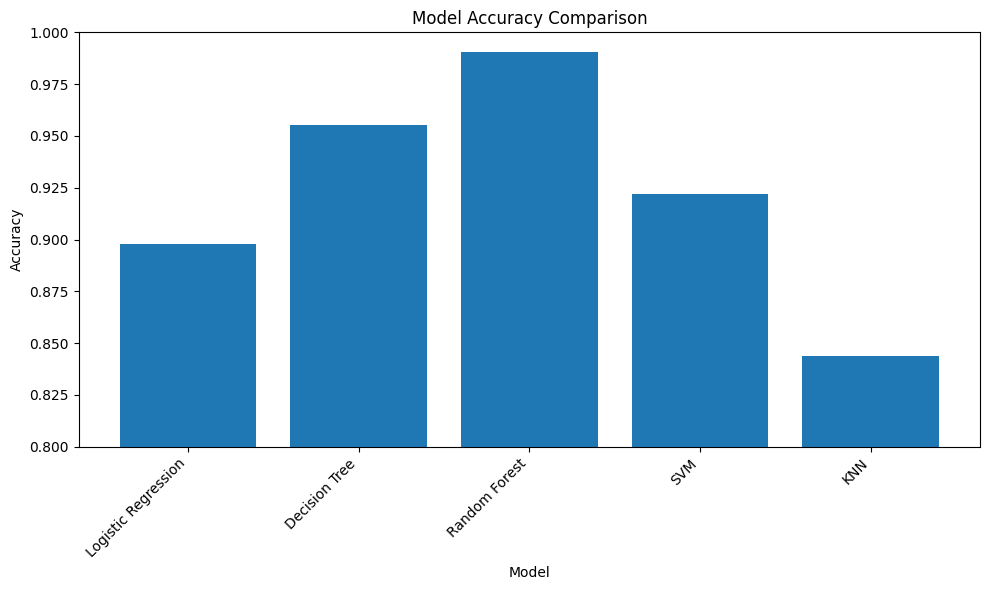

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(evaluation_df.index, evaluation_df['Accuracy'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


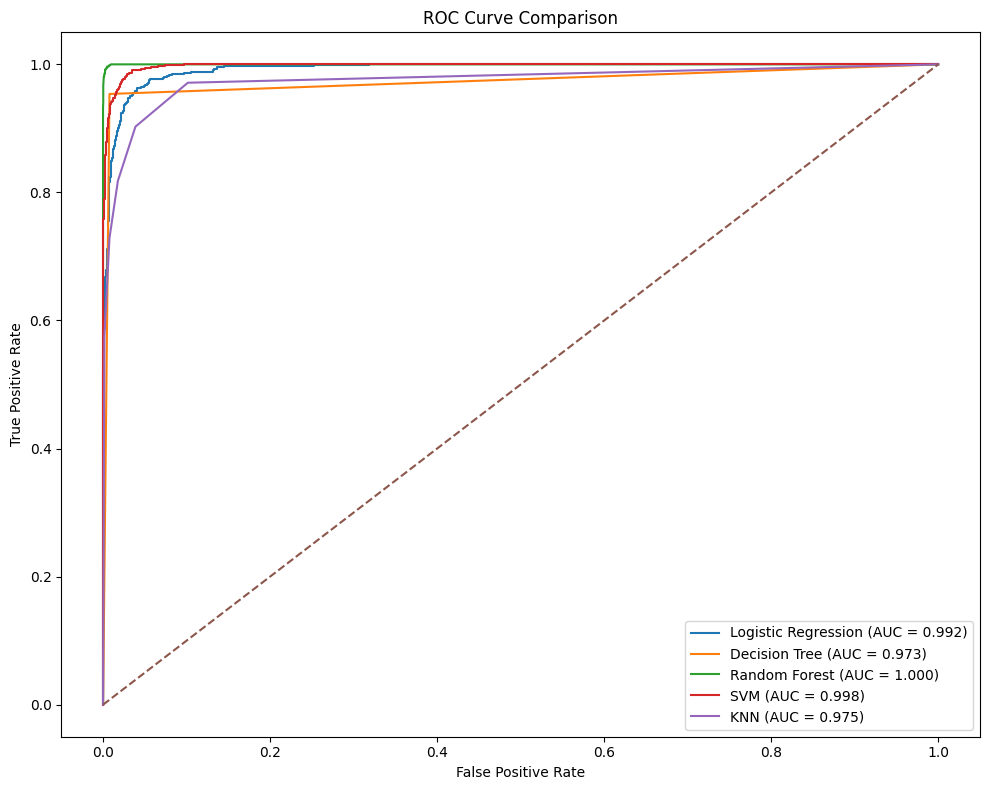

Logistic Regression AUC: 0.992
Decision Tree AUC: 0.973
Random Forest AUC: 1.000
SVM AUC: 0.998
KNN AUC: 0.975


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Make sure the SVM model is set up to return probabilities
if isinstance(models.get("SVM"), SVC) and not models["SVM"].probability:
    models["SVM"] = SVC(probability=True)
    models["SVM"].fit(X_train, y_train)

n_classes = len(np.unique(y_train))
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

auc_scores = {}
plt.figure(figsize=(10, 8))

for name, model in models.items():

    y_score = model.predict_proba(X_test)

    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    auc_scores[name] = roc_auc
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")


plt.plot([0, 1], [0, 1], '--')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Print AUC
for name, score in auc_scores.items():
    print(f"{name} AUC: {score:.3f}")

End of the Project. Extra part is the hyperparameter Tuning


## Hyperparameter Tuning





In [ ]:
# Select best-performing models for tuning
best_models = {
    "Logistic Regression": models["Logistic Regression"],
    "Decision Tree": models["Decision Tree"],
    "Random Forest": models["Random Forest"],
}

print("Models selected for hyperparameter tuning:")
print(list(best_models.keys()))  # cast to list for clean output


Models selected for hyperparameter tuning:
['Logistic Regression', 'Decision Tree', 'Random Forest']


In [ ]:
param_grids = {
    "Logistic Regression": {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs']
    },
    "Decision Tree": {
        'max_depth': [None, 10, 20, 30, 40, 50],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    "Random Forest": {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
}

print("Defined Hyperparameter Grids:")
print(param_grids)


Defined Hyperparameter Grids:
{'Logistic Regression': {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'lbfgs']}, 'Decision Tree': {'max_depth': [None, 10, 20, 30, 40, 50], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}, 'Random Forest': {'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}}


In [ ]:
from sklearn.model_selection import GridSearchCV

tuned_models = {}

for name, model in best_models.items():
    print(f"Performing GridSearchCV for {name}...")
    grid_search = GridSearchCV(
        model,
        param_grids[name],
        cv=5,
        scoring='accuracy',
        n_jobs=-1  # use all cores for speed
    )
    grid_search.fit(X_train, y_train)

    tuned_models[name] = {
        "best_estimator": grid_search.best_estimator_,
        "best_params": grid_search.best_params_,
        "best_score": grid_search.best_score_
    }

    print(f"--- {name} Results ---")
    print(f"Best Parameters: {tuned_models[name]['best_params']}")
    print(f"Best Cross-Validation Score: {tuned_models[name]['best_score']:.4f}\n")

print("Hyperparameter tuning complete. Tuned models and best parameters stored in 'tuned_models'.")


Performing GridSearchCV for Logistic Regression...
--- Logistic Regression Results ---
Best Parameters: {'C': 100, 'solver': 'lbfgs'}
Best Cross-Validation Score: 0.9651

Performing GridSearchCV for Decision Tree...
--- Decision Tree Results ---
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Score: 0.9760

Performing GridSearchCV for Random Forest...
--- Random Forest Results ---
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Score: 0.9932

Hyperparameter tuning complete. Tuned models and best parameters stored in 'tuned_models'.


In [ ]:
tuned_evaluation_results = {}

for name, result in tuned_models.items():
    tuned_model = result['best_estimator']

    print(f"Evaluating Tuned {name}...")
    y_pred_tuned = tuned_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred_tuned)
    report = classification_report(y_test, y_pred_tuned)
    cm = confusion_matrix(y_test, y_pred_tuned)

    tuned_evaluation_results[name] = {
        "accuracy": acc,
        "classification_report": report,
        "confusion_matrix": cm
    }

    print(f"--- Tuned {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Classification Report:\n{report}")
    print(f"Confusion Matrix:\n{cm}\n")


Evaluating Tuned Logistic Regression...
--- Tuned Logistic Regression ---
Accuracy: 0.9553
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        81
           1       0.97      0.92      0.95        85
           2       0.89      0.89      0.89        83
           3       0.90      0.93      0.92        87
           4       0.97      0.97      0.97       105
           5       0.98      0.98      0.98        89
           6       0.99      0.99      0.99        97

    accuracy                           0.96       627
   macro avg       0.95      0.95      0.95       627
weighted avg       0.96      0.96      0.96       627

Confusion Matrix:
[[ 81   0   0   0   0   0   0]
 [  2  78   5   0   0   0   0]
 [  0   2  74   7   0   0   0]
 [  0   0   4  81   2   0   0]
 [  0   0   0   2 102   1   0]
 [  0   0   0   0   1  87   1]
 [  0   0   0   0   0   1  96]]

Evaluating Tuned Decision Tree...
--- Tuned Decision

In [ ]:
# Collect accuracies
initial_accuracies = {
    name: results['accuracy']
    for name, results in evaluation_results.items()
    if name in tuned_models
}
tuned_accuracies = {
    name: results['accuracy']
    for name, results in tuned_evaluation_results.items()
}

# Combine into a DataFrame (align by model names)
accuracy_comparison_df = pd.DataFrame({
    'Initial Accuracy': pd.Series(initial_accuracies),
    'Tuned Accuracy': pd.Series(tuned_accuracies)
})

print("Initial vs Tuned Model Accuracies:")
display(accuracy_comparison_df)


Initial vs Tuned Model Accuracies:


,Initial Accuracy,Tuned Accuracy
Logistic Regression,0.897927,0.955343
Decision Tree,0.953748,0.952153
Random Forest,0.987241,0.985646


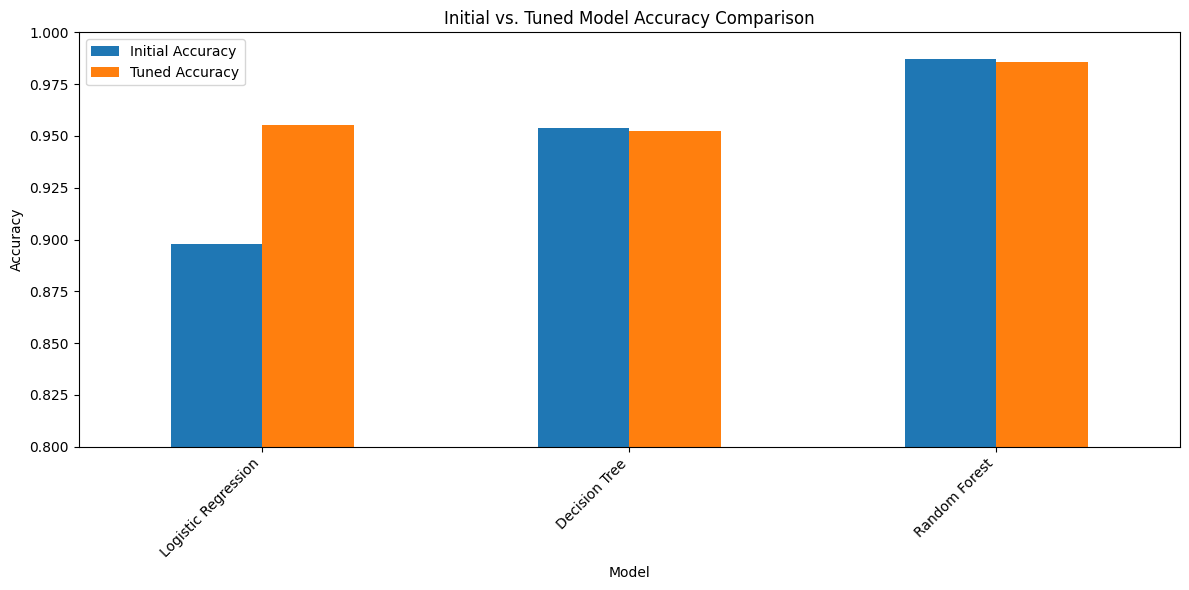

In [ ]:
accuracy_comparison_df.plot(kind='bar', figsize=(12, 6))
plt.title('Initial vs. Tuned Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# Identify the best performing tuned model
best_model_name = max(tuned_evaluation_results, key=lambda k: tuned_evaluation_results[k]['accuracy'])
print(f"The best performing tuned model is: {best_model_name}")

# Get the best estimator
best_tuned_model = tuned_models[best_model_name]['best_estimator']

# Tree-based models → feature importances
if isinstance(best_tuned_model, (RandomForestClassifier, DecisionTreeClassifier)):
    feature_importances = best_tuned_model.feature_importances_
    features_df = pd.DataFrame({'Feature': X_processed.columns, 'Importance': feature_importances})
    features_df = features_df.sort_values(by='Importance', ascending=False)
    print(f"\nFeature Importances ({best_model_name}):")
    display(features_df)

# Logistic Regression → coefficients
elif isinstance(best_tuned_model, LogisticRegression):
    coefs = best_tuned_model.coef_
    # Take mean of absolute coefficients across all classes
    coef_importance = np.mean(np.abs(coefs), axis=0)
    features_df = pd.DataFrame({'Feature': X_processed.columns, 'Coefficient': coef_importance})
    features_df = features_df.sort_values(by='Coefficient', ascending=False)
    print("\nFeature Coefficients (Logistic Regression):")
    display(features_df)


The best performing tuned model is: Random Forest

Feature Importances (Random Forest):


,Feature,Importance
8,BMI,0.419189
2,Weight,0.192991
3,FCVC,0.060062
9,Gender,0.054342
1,Height,0.049192
0,Age,0.049023
4,NCP,0.027016
7,TUE,0.022700
14,family_history_with_overweight,0.022577
6,FAF,0.021729


## Project Summary:

This project aimed to classify individuals into different obesity levels based on various health and lifestyle attributes.

### Data Analysis Key Findings:

*   The dataset contains 2111 entries and 17 features, with the target variable being 'Obesity_Level' (7 classes).
*   Initial data exploration revealed some missing values in 'Gender', 'CH2O', and 'family_history_with_overweight', which were imputed using mode for categorical features and median for numerical features.
*   Duplicate rows were removed, resulting in 2088 unique entries.
*   The target variable 'Obesity_Level' was encoded into a numerical representation (0-6) while preserving the ordinal nature of the classes.
*   Visualizations of numerical features showed their distributions and potential outliers, while count plots of categorical features showed the distribution of categories.
*   Analysis of the relationship between features and the target variable using box plots (numerical vs. obesity level) and stacked bar plots (categorical vs. obesity level) provided insights into feature relevance.
*   A correlation heatmap of numerical features highlighted the strong positive correlation between 'Weight', 'BMI', and 'Obesity\_Level\_Encoded'.

### Model Training and Evaluation:

*   The data was split into training (70%) and testing (30%) sets, with stratification based on the obesity levels to maintain class distribution.
*   Several classification models were trained and evaluated: Logistic Regression, Decision Tree, Random Forest, SVM, and KNN.
*   Initial evaluation showed that Random Forest achieved the highest accuracy (0.9872) on the test set, followed by Decision Tree (0.9537) and SVM (0.9219).
*   ROC curve analysis further supported the strong performance of Random Forest and SVM.

### Hyperparameter Tuning:

*   Hyperparameter tuning using GridSearchCV with 5-fold cross-validation was performed on the top-performing models: Logistic Regression, Decision Tree, and Random Forest.
*   Tuning improved the test accuracy of Logistic Regression (from 0.8979 to 0.9553) and slightly adjusted the performance of Decision Tree (0.9537 to 0.9522) and Random Forest (0.9872 to 0.9856).
*   The best-performing tuned model on the test set remained Random Forest with an accuracy of 0.9856.

### Feature Importance:

*   Analysis of feature importances from the best-performing tuned Random Forest model indicated that 'BMI' and 'Weight' were the most influential features in predicting obesity levels, which aligns with the correlation analysis.

### Conclusion:

The Random Forest classifier, even after hyperparameter tuning, proved to be the most effective model for predicting obesity levels in this dataset, achieving high accuracy on the test set. The study highlights the strong predictive power of BMI and Weight in determining obesity levels. Further improvements could be explored by experimenting with additional feature engineering, exploring more advanced models, or implementing more sophisticated outlier handling techniques.